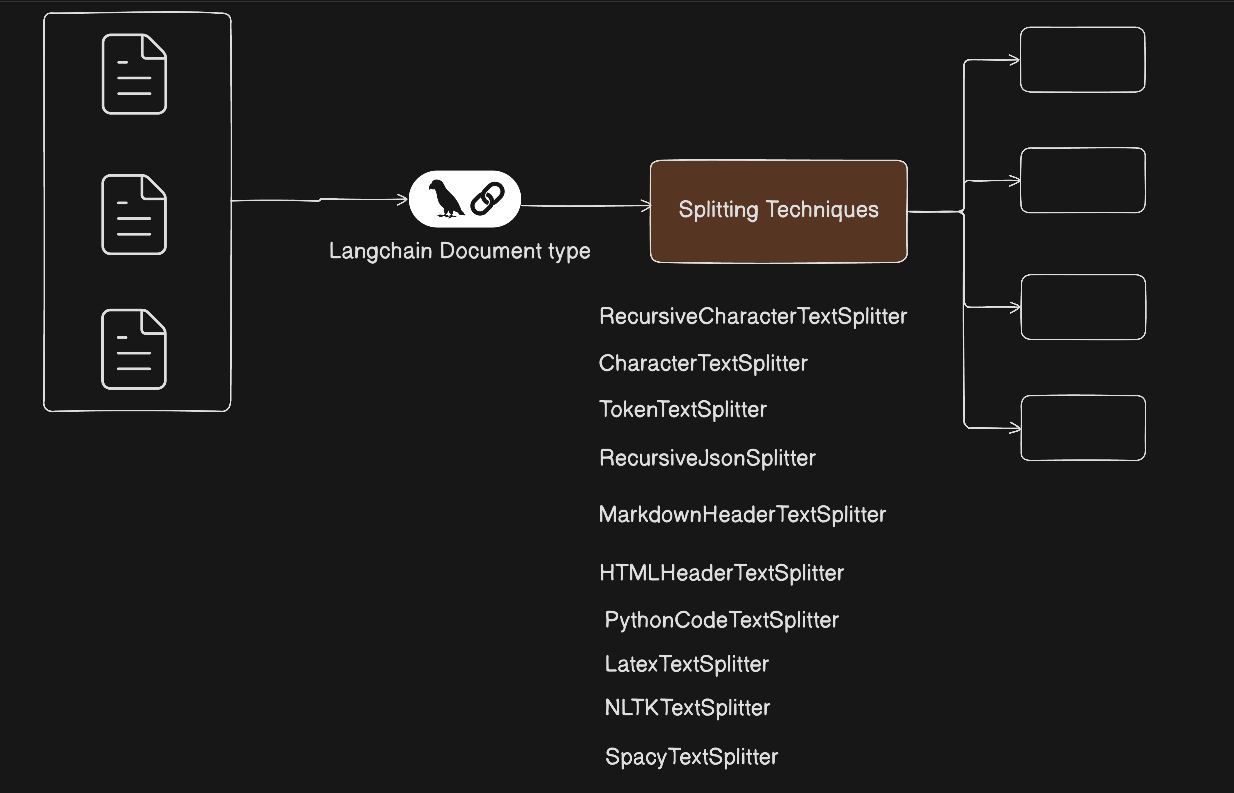

## https://docs.langchain.com/oss/python/integrations/splitters

# Directory loader :
when we have multiple text files

In [ ]:
from langchain_community.document_loaders import DirectoryLoader, TextLoader

dir_loader = DirectoryLoader(
    "data/",
    glob = "*.txt", ##pattern matcher
    loader_cls=TextLoader,
    loader_kwargs={'encoding':'utf-8'},
    show_progress=True
)

documents = dir_loader.load()

/var/folders/m8/jv_qd8md6_n84v8zcshwvjm40000gn/T/ipykernel_57985/3293237476.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader, TextLoader
100%|██████████| 4/4 [00:00<00:00, 1465.13it/s]


In [3]:
for i,doc in enumerate(documents):
    print(f"Documet {i+1}: ")
    print(f"source: {doc.metadata['source']}")
    print(f"Length {len(doc.page_content)}")

Documet 1: 
source: data/python.txt
Length 747
Documet 2: 
source: data/docker.txt
Length 785
Documet 3: 
source: data/kubernetes.txt
Length 748
Documet 4: 
source: data/award.txt
Length 5823


#  Doc splitting

In [5]:
from langchain_text_splitters import CharacterTextSplitter

splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size = 100,
    chunk_overlap = 20,
)

# split the text wherever i find this separator

In [6]:
chunks = splitter.split_documents(documents)

Created a chunk of size 274, which is longer than the specified 100
Created a chunk of size 427, which is longer than the specified 100
Created a chunk of size 275, which is longer than the specified 100
Created a chunk of size 311, which is longer than the specified 100
Created a chunk of size 191, which is longer than the specified 100
Created a chunk of size 381, which is longer than the specified 100
Created a chunk of size 191, which is longer than the specified 100
Created a chunk of size 326, which is longer than the specified 100
Created a chunk of size 257, which is longer than the specified 100
Created a chunk of size 222, which is longer than the specified 100
Created a chunk of size 110, which is longer than the specified 100
Created a chunk of size 204, which is longer than the specified 100
Created a chunk of size 225, which is longer than the specified 100
Created a chunk of size 173, which is longer than the specified 100
Created a chunk of size 130, which is longer tha

In [7]:
chunks

[Document(metadata={'source': 'data/python.txt'}, page_content='Python is a high-level, interpreted,'),
 Document(metadata={'source': 'data/python.txt'}, page_content='general-purpose programming language known for its simple syntax and readability.'),
 Document(metadata={'source': 'data/python.txt'}, page_content='It is widely used in software development, automation, data science, artificial intelligence,'),
 Document(metadata={'source': 'data/python.txt'}, page_content='machine learning, web development, and DevOps. Python provides many built-in libraries and has a large ecosystem of third-party packages. Frameworks such as FastAPI, Flask, and Django help developers build web applications and APIs. Python is also popular in automation because developers can easily write scripts for managing infrastructure, processing files, interacting with APIs, and performing repetitive tasks. Its simplicity and versatility make Python one of the most widely used programming languages in modern te

In [8]:
len(chunks)

47

In [9]:
for i,chunk in enumerate(chunks):
    print(f"\n --- Chunk {i+1} --- ")
    print(f"page content is : {chunk.page_content}")
    print(f"Metadata: {chunk.metadata}")


 --- Chunk 1 --- 
page content is : Python is a high-level, interpreted,
Metadata: {'source': 'data/python.txt'}

 --- Chunk 2 --- 
page content is : general-purpose programming language known for its simple syntax and readability.
Metadata: {'source': 'data/python.txt'}

 --- Chunk 3 --- 
page content is : It is widely used in software development, automation, data science, artificial intelligence,
Metadata: {'source': 'data/python.txt'}

 --- Chunk 4 --- 
page content is : machine learning, web development, and DevOps. Python provides many built-in libraries and has a large ecosystem of third-party packages. Frameworks such as FastAPI, Flask, and Django help developers build web applications and APIs. Python is also popular in automation because developers can easily write scripts for managing infrastructure, processing files, interacting with APIs, and performing repetitive tasks. Its simplicity and versatility make Python one of the most widely used programming languages in modern

In [10]:
text = """ 
Kubernetes is an open-source container orchestration platform used to deploy, 
manage, scale, and automate containerized applications. Originally developed by Google, 
Kubernetes has become a widely used technology in modern cloud-native environments. 
"""

In [14]:
from langchain_text_splitters import CharacterTextSplitter
splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size = 50,
    chunk_overlap = 10,
)

In [15]:
chunks = splitter.split_text(text)

Created a chunk of size 78, which is longer than the specified 50
Created a chunk of size 88, which is longer than the specified 50


In [17]:
chunks[0]

'Kubernetes is an open-source container orchestration platform used to deploy,'

In [18]:
len(chunks)

3

In [22]:
# chunk size = 200 --> words

text = "python is easy"

In [23]:
len(text)

14

python = 6 chars
space = 1
is = 2
space = 1 
easy = 4 chars

In [26]:
text = "python is easy"
print(f" total charcters: {len(text)}")

words = text.split(' ')

for word in words:
    print(f"{word} has {len(word)}-character")

space_count = text.count(' ')
print(f"spaces: {space_count}")

 total charcters: 14
python has 6-character
is has 2-character
easy has 4-character
spaces: 2


chunk_size = 6 --> chunk_overlap = 3

chunk-1 = python
chunk-2 = on is 
chunk-3 = is eas


## Without Overlap


Chunk 1
------------------------------------------------
Created by Guido van Rossum and first released
in 1991
------------------------------------------------


Chunk 2
------------------------------------------------
Python has become one of the most popular
programming languages...
------------------------------------------------



## with overlap:
Chunk 1
------------------------------------------------
Created by Guido van Rossum and first released
in 1991, Python has
------------------------------------------------


Chunk 2
------------------------------------------------
in 1991, Python has become one of the most
popular programming languages...
------------------------------------------------

In [27]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text = """ 
Python is a high-level programming language.
Python is widely used for web development, automation, data science, and artificial intelligence.
Python has simple and readable syntax.
Developers use Python to build applications, APIs, scripts, and machine learning solutions.
"""

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 50,
    chunk_overlap=0
)

chunks = splitter.split_text(text)

In [29]:
len(chunks)

7

In [34]:
for i,chunk in enumerate(chunks):
    print(f"---chunk{i+1}---")
    print(f"total length of the chunk {len(chunk)}")
    print(chunk)

---chunk1---
total length of the chunk 44
Python is a high-level programming language.
---chunk2---
total length of the chunk 42
Python is widely used for web development,
---chunk3---
total length of the chunk 40
automation, data science, and artificial
---chunk4---
total length of the chunk 13
intelligence.
---chunk5---
total length of the chunk 38
Python has simple and readable syntax.
---chunk6---
total length of the chunk 44
Developers use Python to build applications,
---chunk7---
total length of the chunk 46
APIs, scripts, and machine learning solutions.


In [33]:
len(chunks[1])

42

In [40]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text = """ 
 
# Anant Nag and the Dadasaheb Phalke Award: A Golden Recognition for Kannada Cinema

Indian cinema is not just about entertainment. It is a reflection of our culture, language, emotions, traditions and society. Over the decades, many artists have dedicated their lives to enriching Indian cinema. Among them stands a remarkable name from Karnataka — Anant Nag.

In September 2026, veteran actor Anant Nag received the prestigious Dadasaheb Phalke Award for the year 2024, India's highest honour in the field of cinema. President Droupadi Murmu presented the award to him at the 72nd National Film Awards ceremony held at Ekta Nagar, Kevadia, Gujarat, on September 22, 2026.

## What is the Dadasaheb Phalke Award?

The Dadasaheb Phalke Award was instituted by the Government of India in 1969 to commemorate Dadasaheb Phalke, who directed India's first full-length feature film, Raja Harishchandra, in 1913.

The award recognizes outstanding contribution to the growth and development of Indian cinema. It consists of a Swarna Kamal medallion, a shawl and a cash prize of ₹10 lakh. The first recipient was Devika Rani. Over the years, the honour has been presented to legendary personalities such as Satyajit Ray, Raj Kapoor, Lata Mangeshkar, Dr. Rajkumar, Amitabh Bachchan and Rajinikanth.

In 2026, this distinguished list welcomed another important name — Anant Nag.

## The Journey of Anant Nag

Anant Nag was born on September 4, 1948, in Karnataka. His journey into acting began with theatre, and that experience became an important foundation for his distinctive style of performance.

He made his Kannada film debut with Sankalp and later entered Hindi cinema with Shyam Benegal's Ankur. Over a career spanning more than five decades, he has appeared in more than 300 films across Kannada, Hindi, Telugu, Malayalam, Tamil and Marathi cinema. His work also includes the much-loved television series Malgudi Days.

What makes Anant Nag's career particularly significant is his versatility. He has portrayed heroes, ordinary middle-class characters, comic roles, serious dramatic characters and supporting roles with a style that often feels natural rather than theatrical.

President Droupadi Murmu highlighted this quality while presenting the award, describing his acting as a synthesis of the finest elements of theatre and cinema and noting his natural, restrained and authentic performances.

## A Proud Moment for Kannada Cinema

For Karnataka and Kannada-speaking audiences, Anant Nag's recognition carries a special cultural significance.

Kannada cinema has produced many extraordinary artists, filmmakers and writers, but Anant Nag's journey is particularly notable because his career has connected Kannada cinema with audiences across India.

He has spent decades working in Kannada cinema while also contributing to other Indian-language film industries. His ability to bring authenticity to characters made him recognizable to audiences beyond linguistic boundaries.

His Dadasaheb Phalke Award therefore represents not only an individual achievement but also a moment of recognition for the richness and diversity of Indian regional cinema.

## More Than Five Decades of Cinema

Anant Nag's career is an example of longevity in Indian cinema.

The Government of India recognized his five-decade-long contribution to Indian cinema and his influence on generations of artists.

During this journey, he received several major honours, including five Filmfare Awards, five Karnataka State Best Actor Awards, the Karnataka Rajyotsava Award and the Karnataka State Lifetime Achievement Award. He was also awarded the Padma Bhushan in 2025.

But awards alone cannot completely describe an artist's legacy.

A true legacy is created when generations of viewers remember the characters, emotions and performances an actor has given them. In that sense, Anant Nag's contribution extends far beyond the number of films he has acted in.

## His Words After Receiving the Award

During his acceptance speech, Anant Nag reflected on his early journey in theatre and his long career in cinema.

He also spoke about his connection with Karnataka and India, describing Karnataka as his "Karmabhoomi" and India as his "Dharmabhoomi." His speech reflected gratitude toward the people, artists and filmmakers who became part of his journey.

He also recalled the influence of theatre on his career and acknowledged the people who supported him throughout his artistic life.

## An Inspiration for Future Generations

The significance of Anant Nag's Dadasaheb Phalke Award goes beyond one ceremony.

For young actors and aspiring artists, his journey demonstrates the importance of learning, patience, versatility and staying connected to one's craft.

His career also reminds us that Indian cinema is much larger than any single language or industry. Kannada, Hindi, Tamil, Telugu, Malayalam, Marathi and other regional cinemas together form the enormous cultural landscape of Indian cinema.

Anant Nag has been a part of that landscape for more than five decades.

## Conclusion

The Dadasaheb Phalke Award is one of the most significant recognitions an Indian film artist can receive. In 2026, this honour was presented to Anant Nag for his outstanding contribution to Indian cinema.

For Karnataka, Kannada cinema and millions of his admirers, this is a memorable moment.

From theatre to cinema, from Kannada films to national recognition, Anant Nag's journey represents decades of dedication to the art of acting.

His achievement is not simply about receiving another award. It is about celebrating a lifetime devoted to cinema.

Anant Nag's name will now stand among the great artists who have received the Dadasaheb Phalke Award — marking another important chapter in the history of Indian and Kannada cinema.
    
"""

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 50,
    chunk_overlap=20
)

chunks = splitter.split_text(text)

for i,chunk in enumerate(chunks):
    print(f"---chunk{i+1}---")
    print(f"total length of the chunk {len(chunk)}")
    print(chunk)

---chunk1---
total length of the chunk 45
# Anant Nag and the Dadasaheb Phalke Award: A
---chunk2---
total length of the chunk 46
Phalke Award: A Golden Recognition for Kannada
---chunk3---
total length of the chunk 18
for Kannada Cinema
---chunk4---
total length of the chunk 49
Indian cinema is not just about entertainment. It
---chunk5---
total length of the chunk 49
entertainment. It is a reflection of our culture,
---chunk6---
total length of the chunk 46
of our culture, language, emotions, traditions
---chunk7---
total length of the chunk 46
traditions and society. Over the decades, many
---chunk8---
total length of the chunk 46
the decades, many artists have dedicated their
---chunk9---
total length of the chunk 49
dedicated their lives to enriching Indian cinema.
---chunk10---
total length of the chunk 45
Indian cinema. Among them stands a remarkable
---chunk11---
total length of the chunk 47
stands a remarkable name from Karnataka — Anant
---chunk12---
total length of the chunk

In [41]:
from langchain_text_splitters import CharacterTextSplitter

text = """ 
Python is a high-level programming language.
Python is widely used for web development, automation, data science, and artificial intelligence.
Python has simple and readable syntax.
Developers use Python to build applications, APIs, scripts, and machine learning solutions.
"""


splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=500,
    chunk_overlap=50
)

chunks = splitter.split_text(text)

In [43]:
len(chunks)

1

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text = """ 
Python is a high-level programming language.
Python is widely used for web development, automation, data science, and artificial intelligence.
Python has simple and readable syntax.
Developers use Python to build applications, APIs, scripts, and machine learning solutions.
"""


splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunks = splitter.split_text(text)

# \n\n
#\n
# " "
#""

# TokenTextSplitter

In [44]:
# chunk_size = 500 chars

# chunk_size =  500 token

from langchain_text_splitters import TokenTextSplitter

text = """ 
Python is a high-level programming language.
Python is widely used for web development, automation, data science, and artificial intelligence.
Python has simple and readable syntax.
Developers use Python to build applications, APIs, scripts, and machine learning solutions.
"""


splitter = TokenTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunks = splitter.split_text(text)


In [45]:
chunks

[' \nPython is a high-level programming language.\nPython is widely used for web development, automation, data science, and artificial intelligence.\nPython has simple and readable syntax.\nDevelopers use Python to build applications, APIs, scripts, and machine learning solutions.\n']

# 4. MarkdownHeaderTextSplitter

In [46]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

markdown_text = """ 
# Hello Everyone this manoj

```
test

```


"""

headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
]

splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on
)

docs = splitter.split_text(markdown_text)

In [47]:
docs

[Document(metadata={'Header 1': 'Hello Everyone this manoj'}, page_content='```\ntest\n\n```')]